In [9]:
# ============================================================
# STEP 0: IMPORT LIBRARIES & GLOBAL CONFIGURATION
# ============================================================
print("⚙️ STEP 0: IMPORTING LIBRARIES & SETTING ENVIRONMENT")
print("="*70)

# 1. STANDARD PYTHON LIBRARIES
print("\n📦 Importing Standard Libraries...")
import os
import warnings
import urllib.request
print("✅ Standard libraries imported successfully.")

# 2. DATA MANIPULATION LIBRARIES
print("\n📊 Importing Data Analysis Libraries...")
import numpy as np
import pandas as pd
print("✅ NumPy and Pandas loaded.")

# 3. VISUALIZATION LIBRARIES
print("\n📈 Importing Visualization Libraries...")
import matplotlib.pyplot as plt
import seaborn as sns
print("✅ Matplotlib and Seaborn loaded.")

# 4. MACHINE LEARNING LIBRARIES
print("\n🤖 Importing Machine Learning Libraries...")
from sklearn.model_selection import (
    train_test_split,
    learning_curve
)
from sklearn.feature_extraction.text import (
    TfidfVectorizer
)
from sklearn.naive_bayes import (
    MultinomialNB
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)
print("✅ Scikit-learn libraries loaded.")

# 5. GLOBAL CONFIGURATION
print("\n⚙️ Configuring Notebook Environment...")
# Ignore unnecessary warnings
warnings.filterwarnings("ignore")
# Set visualization style
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

print("✅ Warnings disabled.")
print("✅ Seaborn plotting style applied.")
print("✅ Color palette configured.")

# READY TO START
print("\n" + "="*70)
print("🎉 ENVIRONMENT READY")
print("="*70)
print("✔ Libraries Imported Successfully")
print("✔ Visualization Settings Applied")
print("✔ Machine Learning Environment Initialized")
print("✔ Ready for Spam Detection Project 🚀")
print("="*70)

⚙️ STEP 0: IMPORTING LIBRARIES & SETTING ENVIRONMENT

📦 Importing Standard Libraries...
✅ Standard libraries imported successfully.

📊 Importing Data Analysis Libraries...
✅ NumPy and Pandas loaded.

📈 Importing Visualization Libraries...
✅ Matplotlib and Seaborn loaded.

🤖 Importing Machine Learning Libraries...
✅ Scikit-learn libraries loaded.

⚙️ Configuring Notebook Environment...
✅ Warnings disabled.
✅ Seaborn plotting style applied.
✅ Color palette configured.

🎉 ENVIRONMENT READY
✔ Libraries Imported Successfully
✔ Visualization Settings Applied
✔ Machine Learning Environment Initialized
✔ Ready for Spam Detection Project 🚀


In [10]:
# ============================================================
# STEP 1: DATASET LOADING & EXPLORATION
# ============================================================

print("\n" + "="*70)
print("📥 STEP 1: LOADING SPAM DATASET")
print("="*70)


# ============================================================
# 1. DOWNLOAD DATASET
# ============================================================

print("\n🌐 Downloading dataset...")

url_direct = (
    "https://raw.githubusercontent.com/"
    "justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
)

try:
    # Download dataset
    urllib.request.urlretrieve(url_direct, "sms_data.tsv")

    print("✅ Dataset downloaded successfully from GitHub.")

    # Read dataset
    df = pd.read_csv(
        "sms_data.tsv",
        sep="\t",
        header=None,
        names=["label", "message"]
    )

except Exception:

    print("⚠️ Primary source unavailable.")
    print("📦 Loading fallback dataset from Scikit-learn...")

    from sklearn.datasets import fetch_20newsgroups

    ham = fetch_20newsgroups(
        subset="train",
        categories=["rec.sport.baseball"],
        shuffle=True,
        random_state=42
    )

    spam = fetch_20newsgroups(
        subset="train",
        categories=["sci.crypt"],
        shuffle=True,
        random_state=42
    )

    messages = (
        list(ham.data[:1000]) +
        list(spam.data[:1000])
    )

    labels = (
        ["ham"] * 1000 +
        ["spam"] * 1000
    )

    df = pd.DataFrame({
        "label": labels,
        "message": messages
    })

    print("✅ Fallback dataset loaded successfully.")


# ============================================================
# 2. DATASET OVERVIEW
# ============================================================

print("\n" + "-"*70)
print("📊 DATASET OVERVIEW")
print("-"*70)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")


# ============================================================
# 3. FIRST FIVE RECORDS
# ============================================================

print("\n📝 First Five Messages")
print("-"*70)

print(df.head())


# ============================================================
# 4. CLASS DISTRIBUTION
# ============================================================

print("\n📌 Class Distribution")
print("-"*70)

class_counts = df["label"].value_counts()

print(class_counts)

ham_count = class_counts["ham"]
spam_count = class_counts["spam"]

ham_pct = ham_count / len(df) * 100
spam_pct = spam_count / len(df) * 100

print("\n📈 Dataset Statistics")
print("-"*35)

print(f"✅ HAM Messages  : {ham_count:,} ({ham_pct:.2f}%)")
print(f"🚨 SPAM Messages : {spam_count:,} ({spam_pct:.2f}%)")


# ============================================================
# 5. DATA QUALITY CHECK
# ============================================================

print("\n🔍 Data Quality Check")
print("-"*35)

print(f"Missing Values : {df.isnull().sum().sum()}")
print(f"Duplicate Rows : {df.duplicated().sum()}")


# ============================================================
# STEP COMPLETED
# ============================================================

print("\n" + "="*70)
print("🎉 STEP 1 COMPLETED: DATASET READY FOR ANALYSIS")
print("="*70)


📥 STEP 1: LOADING SPAM DATASET

🌐 Downloading dataset...
✅ Dataset downloaded successfully from GitHub.

----------------------------------------------------------------------
📊 DATASET OVERVIEW
----------------------------------------------------------------------
Rows    : 5,572
Columns : 2

📝 First Five Messages
----------------------------------------------------------------------
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

📌 Class Distribution
----------------------------------------------------------------------
label
ham     4825
spam     747
Name: count, dtype: int64

📈 Dataset Statistics
-----------------------------------
✅ HAM Messages  : 4,825 (86.59%)
🚨 SPAM Messages

STEP 2: VISUALIZING SPAM VS HAM PATTERNS


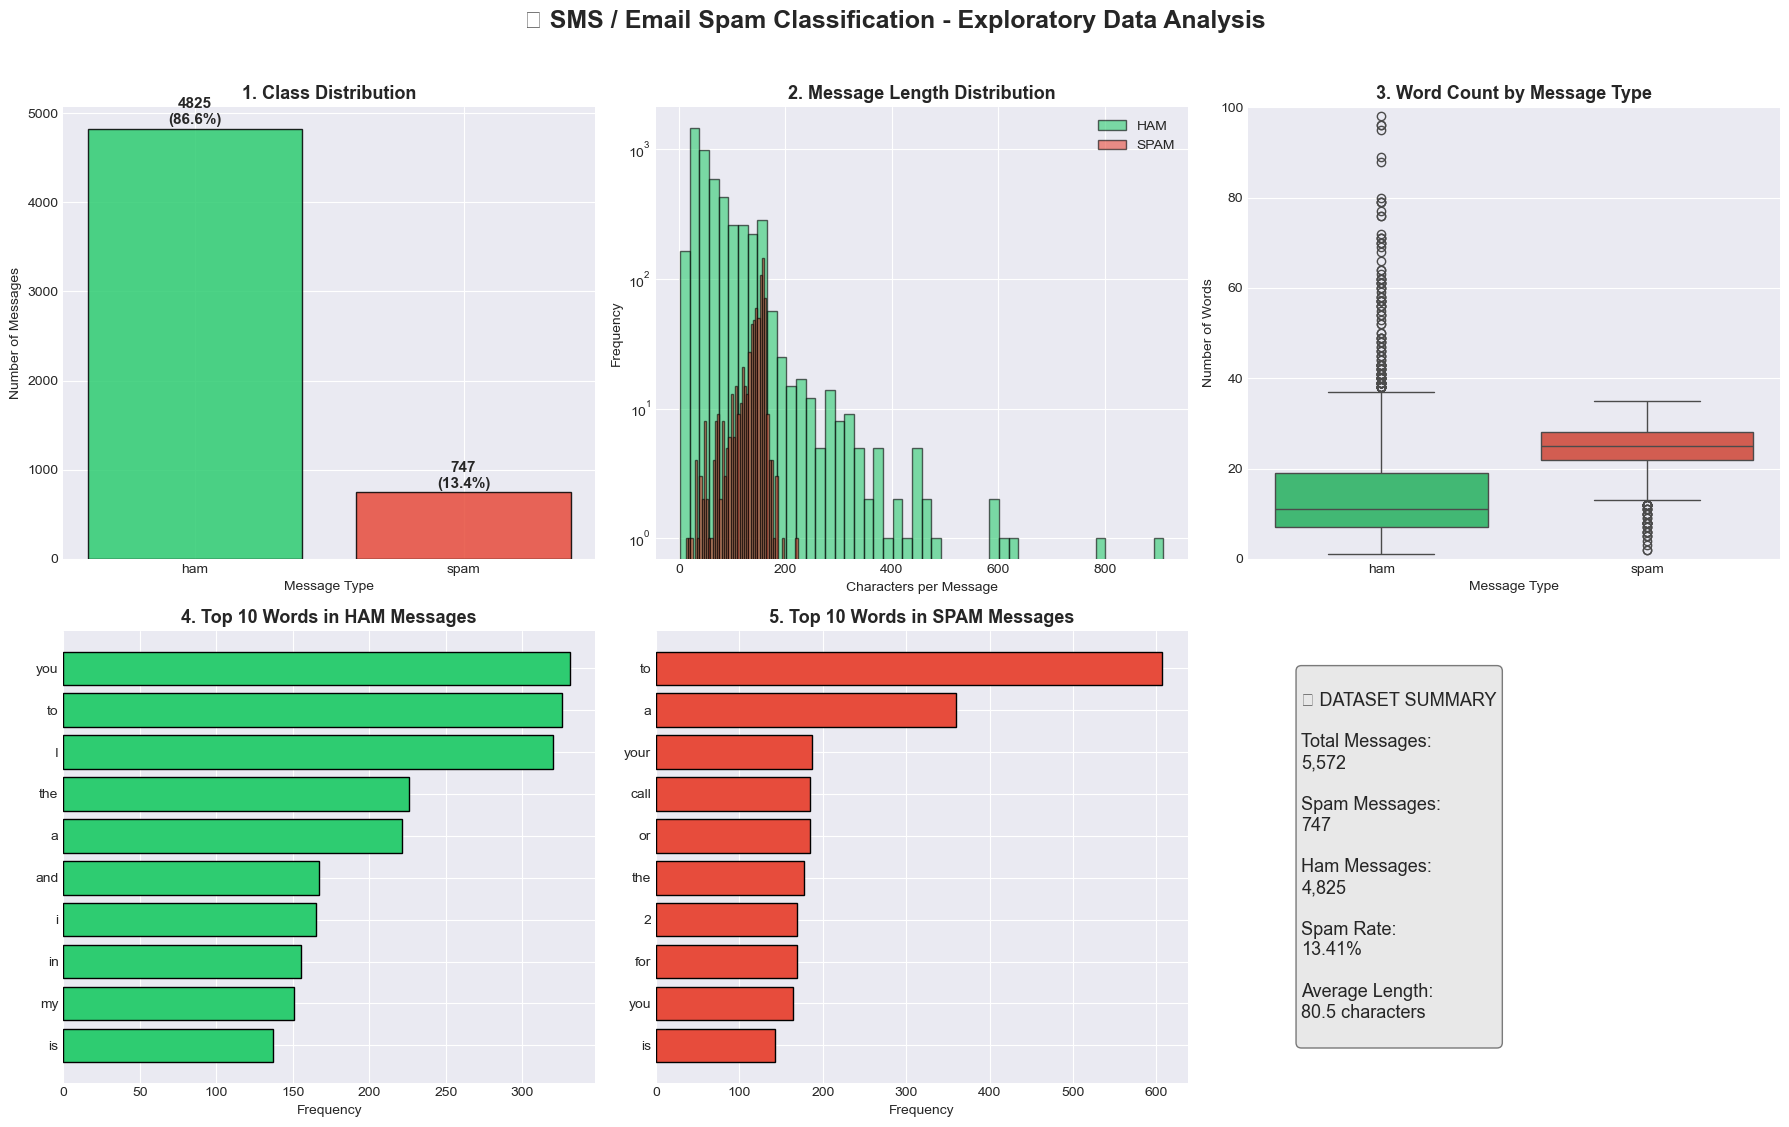

<Figure size 640x480 with 0 Axes>

In [12]:
# ============================================================
# STEP 2: VISUALIZING SPAM VS HAM PATTERNS
# ============================================================

print("STEP 2: VISUALIZING SPAM VS HAM PATTERNS")
print("=" * 55)

from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure layout
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

fig.suptitle(
    "📩 SMS / Email Spam Classification - Exploratory Data Analysis",
    fontsize=18,
    fontweight="bold",
    y=1.02
)


# ============================================================
# 1. CLASS DISTRIBUTION
# ============================================================

ax1 = axes[0, 0]

class_counts = df["label"].value_counts()

colors = ["#2ecc71", "#e74c3c"]

bars = ax1.bar(
    class_counts.index,
    class_counts.values,
    color=colors,
    edgecolor="black",
    alpha=0.85
)

ax1.set_title(
    "1. Class Distribution",
    fontsize=13,
    fontweight="bold"
)

ax1.set_xlabel("Message Type")
ax1.set_ylabel("Number of Messages")


# Add values on bars
for bar, count in zip(bars, class_counts.values):
    percentage = count / len(df) * 100
    
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        f"{count}\n({percentage:.1f}%)",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )



# ============================================================
# 2. MESSAGE LENGTH DISTRIBUTION
# ============================================================

ax2 = axes[0, 1]

df["message_length"] = df["message"].str.len()


for label, color in zip(
    ["ham", "spam"],
    ["#2ecc71", "#e74c3c"]
):

    data = df[df["label"] == label]["message_length"]

    ax2.hist(
        data,
        bins=50,
        alpha=0.6,
        label=label.upper(),
        color=color,
        edgecolor="black"
    )


ax2.set_title(
    "2. Message Length Distribution",
    fontsize=13,
    fontweight="bold"
)

ax2.set_xlabel("Characters per Message")
ax2.set_ylabel("Frequency")

ax2.legend()

# Log scale helps view long-tail distribution
ax2.set_yscale("log")



# ============================================================
# 3. WORD COUNT ANALYSIS
# ============================================================

ax3 = axes[0, 2]


df["word_count"] = (
    df["message"]
    .str.split()
    .str.len()
)


sns.boxplot(
    data=df,
    x="label",
    y="word_count",
    ax=ax3,
    palette=["#2ecc71", "#e74c3c"]
)


ax3.set_title(
    "3. Word Count by Message Type",
    fontsize=13,
    fontweight="bold"
)

ax3.set_xlabel("Message Type")
ax3.set_ylabel("Number of Words")

ax3.set_ylim(0, 100)



# ============================================================
# 4. MOST COMMON WORDS IN HAM
# ============================================================

ax4 = axes[1, 0]


ham_words = (
    " ".join(
        df[df["label"]=="ham"]["message"].head(1000)
    )
    .split()
)


ham_top10 = Counter(ham_words).most_common(10)


words_ham, counts_ham = zip(*ham_top10)


ax4.barh(
    words_ham,
    counts_ham,
    color="#2ecc71",
    edgecolor="black"
)


ax4.set_title(
    "4. Top 10 Words in HAM Messages",
    fontsize=13,
    fontweight="bold"
)

ax4.set_xlabel("Frequency")

ax4.invert_yaxis()



# ============================================================
# 5. MOST COMMON WORDS IN SPAM
# ============================================================

ax5 = axes[1, 1]


spam_words = (
    " ".join(
        df[df["label"]=="spam"]["message"].head(1000)
    )
    .split()
)


spam_top10 = Counter(spam_words).most_common(10)


words_spam, counts_spam = zip(*spam_top10)



ax5.barh(
    words_spam,
    counts_spam,
    color="#e74c3c",
    edgecolor="black"
)


ax5.set_title(
    "5. Top 10 Words in SPAM Messages",
    fontsize=13,
    fontweight="bold"
)

ax5.set_xlabel("Frequency")

ax5.invert_yaxis()



# ============================================================
# 6. EMPTY SPACE / SUMMARY
# ============================================================

ax6 = axes[1, 2]

ax6.axis("off")

summary = f"""
📊 DATASET SUMMARY

Total Messages:
{len(df):,}

Spam Messages:
{class_counts['spam']:,}

Ham Messages:
{class_counts['ham']:,}

Spam Rate:
{class_counts['spam']/len(df)*100:.2f}%

Average Length:
{df['message_length'].mean():.1f} characters
"""


ax6.text(
    0.1,
    0.5,
    summary,
    fontsize=13,
    verticalalignment="center",
    bbox=dict(
        boxstyle="round",
        facecolor="lightgray",
        alpha=0.5
    )
)



# Adjust layout
plt.tight_layout()

plt.show()

# ============================================================
# 6. VOCABULARY ANALYSIS (COMMON VS UNIQUE WORDS)
# ============================================================

ax6 = axes[1, 2]


# Extract words from HAM and SPAM messages
ham_words_all = (
    " ".join(
        df[df["label"] == "ham"]["message"]
    )
    .split()
)

spam_words_all = (
    " ".join(
        df[df["label"] == "spam"]["message"]
    )
    .split()
)


# Convert lists into sets
ham_set = set(ham_words_all)
spam_set = set(spam_words_all)


# Calculate word categories
common_words = len(ham_set.intersection(spam_set))

unique_ham = len(
    ham_set - spam_set
)

unique_spam = len(
    spam_set - ham_set
)


# Prepare visualization data
word_categories = [
    "Common Words",
    "Unique HAM",
    "Unique SPAM"
]

word_counts = [
    common_words,
    unique_ham,
    unique_spam
]


# Create bar chart
bars = ax6.bar(
    word_categories,
    word_counts,
    color=[
        "#95a5a6",
        "#2ecc71",
        "#e74c3c"
    ],
    edgecolor="black",
    alpha=0.85
)


# Chart title and labels
ax6.set_title(
    "6. Vocabulary Analysis",
    fontsize=13,
    fontweight="bold"
)

ax6.set_ylabel(
    "Number of Unique Words"
)


# Rotate x-axis labels
ax6.tick_params(
    axis="x",
    rotation=25
)


# Add values on bars
for bar, value in zip(bars, word_counts):
    
    ax6.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        f"{value:,}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )


# Improve spacing
plt.tight_layout()

plt.show()

In [13]:
# ============================================================
# STEP 3: TEXT PREPROCESSING & FEATURE ENGINEERING
# ============================================================

print("\n" + "="*65)
print("📝 STEP 3: TEXT PREPROCESSING & FEATURE ENGINEERING")
print("="*65)


# ============================================================
# 1. LABEL ENCODING
# ============================================================

print("\n🔹 1. Converting Labels into Binary Format")
print("-"*45)

# Spam = 1, Ham = 0
y = (df["label"] == "spam").astype(int)

X_text = df["message"]


print("✅ Label Encoding Completed")
print("   Ham  → 0")
print("   Spam → 1")

print(f"\nTotal Samples: {len(y):,}")
print(f"Spam Samples: {sum(y):,}")
print(f"Ham Samples: {len(y)-sum(y):,}")



# ============================================================
# 2. TF-IDF FEATURE EXTRACTION
# ============================================================

print("\n" + "-"*65)
print("🔹 2. TF-IDF Feature Extraction")
print("-"*65)


vectorizer = TfidfVectorizer(
    max_features=3000,      # Keep top 3000 important words
    stop_words="english",   # Remove common words
    ngram_range=(1,2),      # Use single words + two-word combinations
    lowercase=True,         # Convert text to lowercase
    max_df=0.8,             # Remove very common words
    min_df=2                # Remove rare words
)


# Convert text into numerical features
X = vectorizer.fit_transform(X_text)



print("✅ TF-IDF Transformation Completed")

print(f"\n📊 Feature Matrix Information")
print("-"*35)

print(f"Number of Messages : {X.shape[0]:,}")
print(f"Number of Features: {X.shape[1]:,}")


print("\n🔤 Sample Extracted Features:")
print(vectorizer.get_feature_names_out()[:15])



# ============================================================
# 3. TRAIN-TEST SPLIT
# ============================================================

print("\n" + "-"*65)
print("🔹 3. Stratified Train-Test Split")
print("-"*65)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("✅ Dataset Successfully Split")


print("\n📚 Dataset Distribution")
print("-"*35)

print(f"Training Samples : {X_train.shape[0]:,}")
print(f"Testing Samples  : {X_test.shape[0]:,}")



# ============================================================
# 4. BASELINE PERFORMANCE
# ============================================================

print("\n" + "-"*65)
print("🔹 4. Baseline Accuracy")
print("-"*65)


baseline_accuracy = (
    max(y.value_counts(normalize=True)) * 100
)


print(
    f"📌 Baseline Accuracy: {baseline_accuracy:.2f}%"
)


print("\n" + "="*65)
print("✅ STEP 3 COMPLETED SUCCESSFULLY")
print("="*65)


📝 STEP 3: TEXT PREPROCESSING & FEATURE ENGINEERING

🔹 1. Converting Labels into Binary Format
---------------------------------------------
✅ Label Encoding Completed
   Ham  → 0
   Spam → 1

Total Samples: 5,572
Spam Samples: 747
Ham Samples: 4,825

-----------------------------------------------------------------
🔹 2. TF-IDF Feature Extraction
-----------------------------------------------------------------
✅ TF-IDF Transformation Completed

📊 Feature Matrix Information
-----------------------------------
Number of Messages : 5,572
Number of Features: 3,000

🔤 Sample Extracted Features:
['00' '00 sub' '000' '000 bonus' '000 cash' '000 prize' '02' '03' '03 2nd'
 '04' '05' '06' '06 03' '0800' '0800 542']

-----------------------------------------------------------------
🔹 3. Stratified Train-Test Split
-----------------------------------------------------------------
✅ Dataset Successfully Split

📚 Dataset Distribution
-----------------------------------
Training Samples : 4,457
Test

In [14]:
# ============================================================
# STEP 4: TRAINING NAIVE BAYES CLASSIFIER
# ============================================================

print("\n" + "="*65)
print("🤖 STEP 4: TRAINING NAIVE BAYES CLASSIFIER")
print("="*65)


# ============================================================
# 1. INITIALIZE MODEL
# ============================================================

print("\n🔹 1. Initializing Multinomial Naive Bayes Model")
print("-"*50)


model = MultinomialNB(
    alpha=0.5
)


print("✅ Model initialized successfully")
print(f"   Smoothing Parameter (alpha): {model.alpha}")



# ============================================================
# 2. TRAIN THE MODEL
# ============================================================

print("\n" + "-"*65)
print("🔹 2. Training Model")
print("-"*65)


model.fit(
    X_train,
    y_train
)


print("✅ Model trained successfully!")



# ============================================================
# 3. TRAINING INFORMATION
# ============================================================

print("\n" + "-"*65)
print("📊 Training Information")
print("-"*65)


print(f"Training Samples : {X_train.shape[0]:,}")
print(f"Features Used    : {X_train.shape[1]:,}")

print("\nClass Mapping:")
print("   0 → Ham Message")
print("   1 → Spam Message")



# ============================================================
# COMPLETION MESSAGE
# ============================================================

print("\n" + "="*65)
print("🎉 STEP 4 COMPLETED: NAIVE BAYES MODEL READY FOR PREDICTION")
print("="*65)


🤖 STEP 4: TRAINING NAIVE BAYES CLASSIFIER

🔹 1. Initializing Multinomial Naive Bayes Model
--------------------------------------------------
✅ Model initialized successfully
   Smoothing Parameter (alpha): 0.5

-----------------------------------------------------------------
🔹 2. Training Model
-----------------------------------------------------------------
✅ Model trained successfully!

-----------------------------------------------------------------
📊 Training Information
-----------------------------------------------------------------
Training Samples : 4,457
Features Used    : 3,000

Class Mapping:
   0 → Ham Message
   1 → Spam Message

🎉 STEP 4 COMPLETED: NAIVE BAYES MODEL READY FOR PREDICTION



📈 STEP 5: GENERATING TRAINING CURVES

🔹 1. Calculating Learning Curve
--------------------------------------------------
✅ Learning curve generated successfully!

🔹 2. Processing Training Results
--------------------------------------------------
✅ Score analysis completed

🔹 3. Displaying Learning Curve
--------------------------------------------------

🔍 Model Fit Analysis
--------------------------------------------------
Final Training Accuracy   : 0.9890
Final Validation Accuracy : 0.9851
Accuracy Gap              : 0.0039


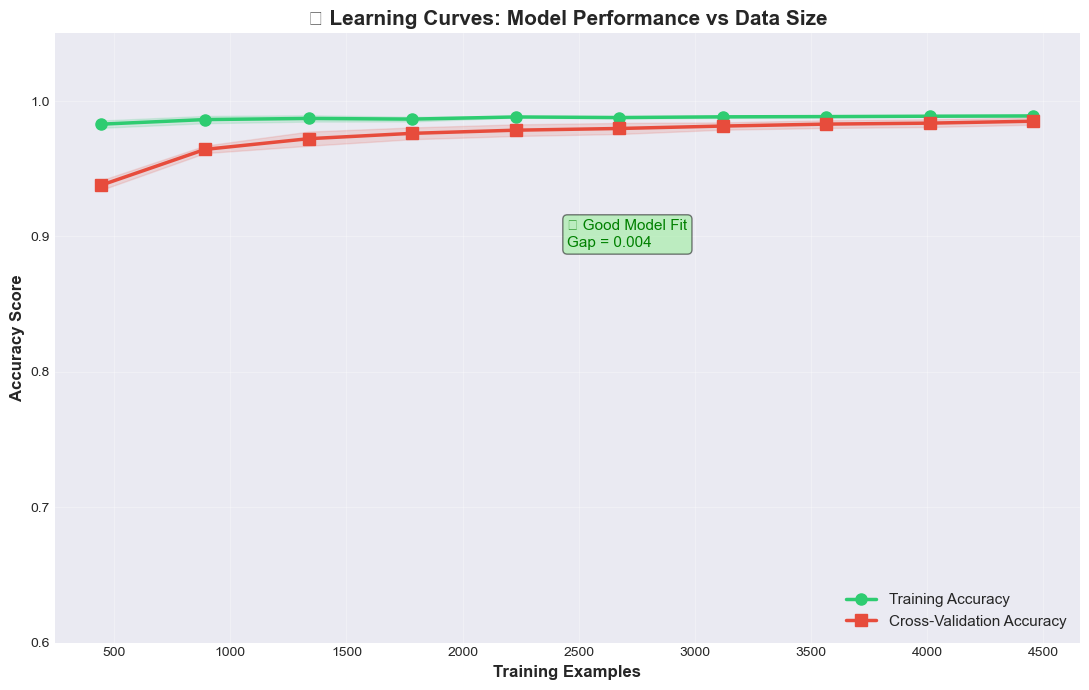


🎉 STEP 5 COMPLETED: TRAINING CURVE ANALYSIS FINISHED


In [15]:
# ============================================================
# STEP 5: GENERATING TRAINING CURVES
# ============================================================

print("\n" + "="*65)
print("📈 STEP 5: GENERATING TRAINING CURVES")
print("="*65)


# ============================================================
# 1. CALCULATE LEARNING CURVE
# ============================================================

print("\n🔹 1. Calculating Learning Curve")
print("-"*50)


train_sizes, train_scores, test_scores = learning_curve(
    model,
    X,
    y,
    cv=5,                              # 5-fold cross validation
    n_jobs=-1,                         # Use all CPU cores
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)


print("✅ Learning curve generated successfully!")



# ============================================================
# 2. CALCULATE MEAN AND STANDARD DEVIATION
# ============================================================

print("\n🔹 2. Processing Training Results")
print("-"*50)


# Training score statistics
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)


# Validation score statistics
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)


print("✅ Score analysis completed")



# ============================================================
# 3. VISUALIZE LEARNING CURVES
# ============================================================

print("\n🔹 3. Displaying Learning Curve")
print("-"*50)


fig, ax = plt.subplots(
    figsize=(11, 7)
)


# Confidence intervals
ax.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15,
    color="#2ecc71"
)


ax.fill_between(
    train_sizes,
    test_mean - test_std,
    test_mean + test_std,
    alpha=0.15,
    color="#e74c3c"
)



# Training accuracy curve
ax.plot(
    train_sizes,
    train_mean,
    "o-",
    color="#2ecc71",
    linewidth=2.5,
    markersize=8,
    label="Training Accuracy"
)



# Validation accuracy curve
ax.plot(
    train_sizes,
    test_mean,
    "s-",
    color="#e74c3c",
    linewidth=2.5,
    markersize=8,
    label="Cross-Validation Accuracy"
)



# Chart formatting
ax.set_xlabel(
    "Training Examples",
    fontsize=12,
    fontweight="bold"
)


ax.set_ylabel(
    "Accuracy Score",
    fontsize=12,
    fontweight="bold"
)


ax.set_title(
    "📊 Learning Curves: Model Performance vs Data Size",
    fontsize=15,
    fontweight="bold"
)


ax.legend(
    loc="lower right",
    fontsize=11
)


ax.grid(
    True,
    alpha=0.3
)


ax.set_ylim(
    [0.6, 1.05]
)



# ============================================================
# 4. CHECK OVERFITTING / UNDERFITTING
# ============================================================

gap = train_mean[-1] - test_mean[-1]


print("\n🔍 Model Fit Analysis")
print("-"*50)

print(f"Final Training Accuracy   : {train_mean[-1]:.4f}")
print(f"Final Validation Accuracy : {test_mean[-1]:.4f}")
print(f"Accuracy Gap              : {gap:.4f}")



if gap > 0.10:

    message = (
        f"⚠️ Overfitting detected\n"
        f"Gap = {gap:.3f}"
    )

    ax.text(
        0.5,
        0.65,
        message,
        transform=ax.transAxes,
        fontsize=11,
        color="red",
        bbox=dict(
            boxstyle="round",
            facecolor="yellow",
            alpha=0.5
        )
    )


else:

    message = (
        f"✅ Good Model Fit\n"
        f"Gap = {gap:.3f}"
    )

    ax.text(
        0.5,
        0.65,
        message,
        transform=ax.transAxes,
        fontsize=11,
        color="green",
        bbox=dict(
            boxstyle="round",
            facecolor="lightgreen",
            alpha=0.5
        )
    )



plt.tight_layout()

plt.show()



print("\n" + "="*65)
print("🎉 STEP 5 COMPLETED: TRAINING CURVE ANALYSIS FINISHED")
print("="*65)

In [16]:
# ============================================================
# STEP 6: MODEL EVALUATION
# ============================================================

print("\n" + "="*65)
print("📊 STEP 6: MODEL EVALUATION")
print("="*65)


# ============================================================
# 1. MAKE PREDICTIONS
# ============================================================

print("\n🔹 1. Generating Predictions")
print("-"*50)


# Predict class labels
y_pred = model.predict(X_test)


# Predict probability of spam
y_pred_proba = model.predict_proba(X_test)[:, 1]


print("✅ Predictions generated successfully!")



# ============================================================
# 2. CALCULATE CLASSIFICATION METRICS
# ============================================================

print("\n🔹 2. Calculating Performance Metrics")
print("-"*50)


accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)



# ============================================================
# 3. DISPLAY METRICS
# ============================================================

print("\n📈 CLASSIFICATION PERFORMANCE")
print("="*50)


print(f"✅ Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"✅ Precision : {precision:.4f}  ({precision*100:.2f}%)")
print(f"✅ Recall    : {recall:.4f}  ({recall*100:.2f}%)")
print(f"✅ F1-Score  : {f1:.4f}  ({f1*100:.2f}%)")



# ============================================================
# 4. DETAILED CLASSIFICATION REPORT
# ============================================================

print("\n" + "="*65)
print("📋 DETAILED CLASSIFICATION REPORT")
print("="*65)


print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "HAM (0)",
            "SPAM (1)"
        ]
    )
)



# ============================================================
# 5. FINAL MODEL SUMMARY
# ============================================================

print("="*65)
print("🎯 MODEL SUMMARY")
print("="*65)

print(f"Model Type           : Multinomial Naive Bayes")
print(f"Testing Samples      : {X_test.shape[0]:,}")
print(f"Features Used        : {X_test.shape[1]:,}")
print(f"Accuracy             : {accuracy*100:.2f}%")
print(f"F1 Score             : {f1*100:.2f}%")



print("\n" + "="*65)
print("🎉 STEP 6 COMPLETED: MODEL EVALUATION FINISHED")
print("="*65)


📊 STEP 6: MODEL EVALUATION

🔹 1. Generating Predictions
--------------------------------------------------
✅ Predictions generated successfully!

🔹 2. Calculating Performance Metrics
--------------------------------------------------

📈 CLASSIFICATION PERFORMANCE
✅ Accuracy  : 0.9812  (98.12%)
✅ Precision : 0.9923  (99.23%)
✅ Recall    : 0.8658  (86.58%)
✅ F1-Score  : 0.9247  (92.47%)

📋 DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

     HAM (0)       0.98      1.00      0.99       966
    SPAM (1)       0.99      0.87      0.92       149

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.96      1115
weighted avg       0.98      0.98      0.98      1115

🎯 MODEL SUMMARY
Model Type           : Multinomial Naive Bayes
Testing Samples      : 1,115
Features Used        : 3,000
Accuracy             : 98.12%
F1 Score             : 92.47%

🎉 STEP 6 COMPLETED: MODEL EVALUATION FINISHED



📊 STEP 7: COMPREHENSIVE VISUAL EVALUATION


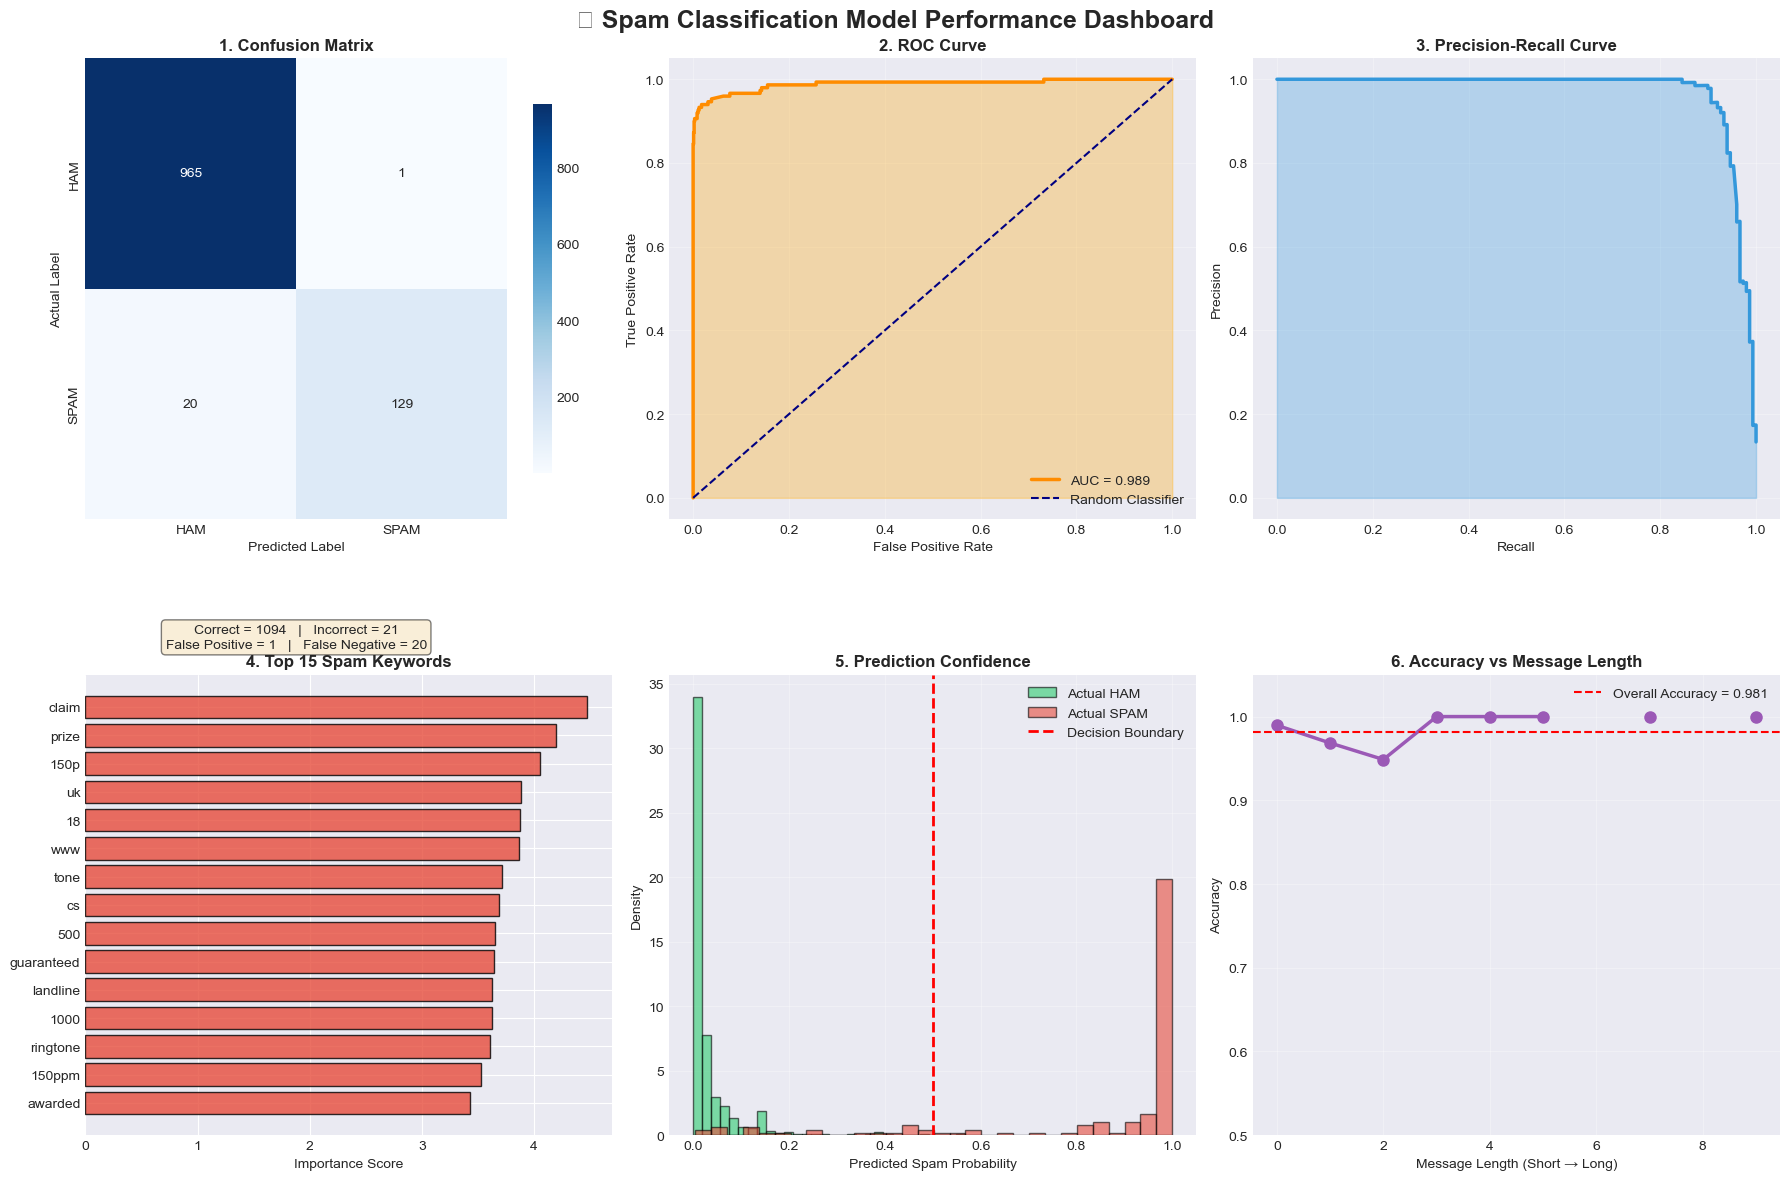


🎉 STEP 7 COMPLETED: VISUAL MODEL EVALUATION FINISHED


In [17]:
# ============================================================
# STEP 7: COMPREHENSIVE VISUAL EVALUATION
# ============================================================

print("\n" + "="*70)
print("📊 STEP 7: COMPREHENSIVE VISUAL EVALUATION")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(
    "📩 Spam Classification Model Performance Dashboard",
    fontsize=18,
    fontweight="bold"
)

# ============================================================
# 1. CONFUSION MATRIX
# ============================================================

ax1 = axes[0, 0]

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["HAM", "SPAM"],
    yticklabels=["HAM", "SPAM"],
    cbar_kws={"shrink": 0.8},
    ax=ax1
)

ax1.set_title("1. Confusion Matrix", fontweight="bold")
ax1.set_xlabel("Predicted Label")
ax1.set_ylabel("Actual Label")

tn, fp, fn, tp = cm.ravel()

ax1.text(
    0.5,
    -0.28,
    f"Correct = {tn+tp}   |   Incorrect = {fp+fn}\n"
    f"False Positive = {fp}   |   False Negative = {fn}",
    transform=ax1.transAxes,
    ha="center",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5)
)

# ============================================================
# 2. ROC CURVE
# ============================================================

ax2 = axes[0, 1]

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

ax2.plot(
    fpr,
    tpr,
    color="darkorange",
    linewidth=2.5,
    label=f"AUC = {roc_auc:.3f}"
)

ax2.plot(
    [0,1],
    [0,1],
    "--",
    color="navy",
    label="Random Classifier"
)

ax2.fill_between(
    fpr,
    tpr,
    alpha=0.3,
    color="orange"
)

ax2.set_title("2. ROC Curve", fontweight="bold")
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.legend(loc="lower right")
ax2.grid(alpha=0.3)

# ============================================================
# 3. PRECISION-RECALL CURVE
# ============================================================

ax3 = axes[0, 2]

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_pred_proba
)

ax3.plot(
    recall_curve,
    precision_curve,
    color="#3498db",
    linewidth=2.5
)

ax3.fill_between(
    recall_curve,
    precision_curve,
    alpha=0.3,
    color="#3498db"
)

ax3.set_title("3. Precision-Recall Curve", fontweight="bold")
ax3.set_xlabel("Recall")
ax3.set_ylabel("Precision")
ax3.grid(alpha=0.3)

# ============================================================
# 4. TOP SPAM INDICATORS
# ============================================================

ax4 = axes[1, 0]

feature_names = vectorizer.get_feature_names_out()

importance = (
    model.feature_log_prob_[1]
    - model.feature_log_prob_[0]
)

feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_df = feature_df.sort_values(
    "Importance",
    ascending=False
).head(15)

ax4.barh(
    feature_df["Feature"],
    feature_df["Importance"],
    color="#e74c3c",
    edgecolor="black",
    alpha=0.8
)

ax4.set_title("4. Top 15 Spam Keywords", fontweight="bold")
ax4.set_xlabel("Importance Score")
ax4.invert_yaxis()

# ============================================================
# 5. PREDICTION CONFIDENCE
# ============================================================

ax5 = axes[1, 1]

spam_prob = y_pred_proba[y_test == 1]
ham_prob = y_pred_proba[y_test == 0]

ax5.hist(
    ham_prob,
    bins=30,
    alpha=0.6,
    density=True,
    color="#2ecc71",
    edgecolor="black",
    label="Actual HAM"
)

ax5.hist(
    spam_prob,
    bins=30,
    alpha=0.6,
    density=True,
    color="#e74c3c",
    edgecolor="black",
    label="Actual SPAM"
)

ax5.axvline(
    0.5,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Decision Boundary"
)

ax5.set_title("5. Prediction Confidence", fontweight="bold")
ax5.set_xlabel("Predicted Spam Probability")
ax5.set_ylabel("Density")
ax5.legend()
ax5.grid(alpha=0.3)

# ============================================================
# 6. PERFORMANCE VS MESSAGE LENGTH
# ============================================================

ax6 = axes[1, 2]

test_lengths = df.loc[y_test.index, "message_length"]

evaluation_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Length": test_lengths.values
})

evaluation_df["Length Bin"] = pd.cut(
    evaluation_df["Length"],
    bins=10
)

accuracy_by_length = (
    evaluation_df
    .groupby("Length Bin", observed=False)
    .apply(lambda x: accuracy_score(x["Actual"], x["Predicted"]))
)

ax6.plot(
    range(len(accuracy_by_length)),
    accuracy_by_length.values,
    "o-",
    color="#9b59b6",
    linewidth=2.5,
    markersize=8
)

ax6.axhline(
    accuracy,
    color="red",
    linestyle="--",
    label=f"Overall Accuracy = {accuracy:.3f}"
)

ax6.set_title("6. Accuracy vs Message Length", fontweight="bold")
ax6.set_xlabel("Message Length (Short → Long)")
ax6.set_ylabel("Accuracy")
ax6.set_ylim(0.5, 1.05)
ax6.grid(alpha=0.3)
ax6.legend()

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("🎉 STEP 7 COMPLETED: VISUAL MODEL EVALUATION FINISHED")
print("="*70)

In [18]:
# ============================================================
# STEP 8: LIVE SPAM DETECTION DEMO
# ============================================================

print("\n" + "="*70)
print("📱 STEP 8: LIVE SPAM DETECTION DEMONSTRATION")
print("="*70)


# ============================================================
# SAMPLE MESSAGES FOR TESTING
# ============================================================

test_messages = [
    "Congratulations! You've won a free iPhone! Click here to claim now!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your account has been compromised. Verify now: bit.ly/xxx",
    "The meeting has been rescheduled to 3pm. Thanks!",
    "FREE entry to win $1000 gift card! Text WIN to 12345",
    "Don't forget to submit your report by Friday."
]

print(f"\n📨 Testing {len(test_messages)} Sample Messages")
print("-"*70)


# ============================================================
# PREDICT EACH MESSAGE
# ============================================================

for i, msg in enumerate(test_messages, start=1):

    # Convert message into TF-IDF features
    msg_vector = vectorizer.transform([msg])

    # Predict class
    prediction = model.predict(msg_vector)[0]

    # Predict spam probability
    probability = model.predict_proba(msg_vector)[0][1]

    # Convert prediction into label
    if prediction == 1:
        label = "🚨 SPAM"
        confidence = probability
    else:
        label = "✅ HAM"
        confidence = 1 - probability

    # Display results
    print(f"\n📩 Message {i}")
    print("-"*70)
    print(f"Message    : {msg}")
    print(f"Prediction : {label}")
    print(f"Confidence : {confidence:.2%}")


# ============================================================
# OPTIONAL: CLEANUP
# ============================================================

print("\n" + "-"*70)

if os.path.exists("sms_data.tsv"):
    os.remove("sms_data.tsv")
    print("🗑️ Temporary dataset removed successfully.")
else:
    print("ℹ️ No temporary dataset found.")

print("-"*70)

print("\n" + "="*70)
print("🎉 STEP 8 COMPLETED: LIVE SPAM DETECTION SUCCESSFUL")
print("="*70)


📱 STEP 8: LIVE SPAM DETECTION DEMONSTRATION

📨 Testing 6 Sample Messages
----------------------------------------------------------------------

📩 Message 1
----------------------------------------------------------------------
Message    : Congratulations! You've won a free iPhone! Click here to claim now!
Prediction : 🚨 SPAM
Confidence : 91.83%

📩 Message 2
----------------------------------------------------------------------
Message    : Hey, are we still meeting for lunch tomorrow?
Prediction : ✅ HAM
Confidence : 99.83%

📩 Message 3
----------------------------------------------------------------------
Message    : URGENT: Your account has been compromised. Verify now: bit.ly/xxx
Prediction : ✅ HAM
Confidence : 83.41%

📩 Message 4
----------------------------------------------------------------------
Message    : The meeting has been rescheduled to 3pm. Thanks!
Prediction : ✅ HAM
Confidence : 98.72%

📩 Message 5
--------------------------------------------------------------------